In [ ]:
"""Calculates and plots the magnetic field due to 2 rectangular magnets"""

import numpy as np
import polars as pl

import pymagnet as pm
import pymagnet.plots as mplt

width = 12.0
height = 6.0
unit = "mm"
Jr = 1.26


def gen_alternating_magnets(N=5, width=width, height=height, Jr=Jr):
    """Generate N rectangular magnets with alternating remanence (+/-Jr),
    keeping phi=90.0 for all magnets, centered along x."""

    # Center the array along x
    x0 = -(N - 1) * width / 2
    y0 = -height / 2 - 0.01  # slight offset to avoid perfect grid alignment issues

    for i in range(N):
        center = (x0, y0)

        # Smart alternation of Jr sign
        Jr_i = Jr * (-1) ** i

        _ = pm.magnets.Rectangle(
            width=width, height=height, Jr=Jr_i, center=center, phi=90.0
        )

        x0 += width




def gen_lin_halbach(N=5, width=width, height=height, Jr=Jr):
    """Generate a linear Halbach array of N magnets (N >= 1),
    keeping the same orientation change pattern as the original:
    [LEFT(-Jr,0), DOWN(-Jr,90), RIGHT(+Jr,0), UP(+Jr,90)] repeating."""

    # Starting position and row (same as original code)
    x0 = -(N - 1) * width / 2
    y0 = -height / 2 - 0.01  # slight offset to avoid perfect grid alignment issues

    for i in range(N):
        center = (x0, y0)
        idx = i % 4

        if idx == 0:  # LEFT
            phi = 0.0
            Jr_i = -Jr
        elif idx == 1:  # DOWN
            phi = 90.0
            Jr_i = -Jr
        elif idx == 2:  # RIGHT
            phi = 0.0
            Jr_i = Jr
        else:  # UP
            phi = 90.0
            Jr_i = Jr

        _ = pm.magnets.Rectangle(
            width=width, height=height, Jr=Jr_i, center=center, phi=phi
        )

        x0 += width  # move to the next slot along x




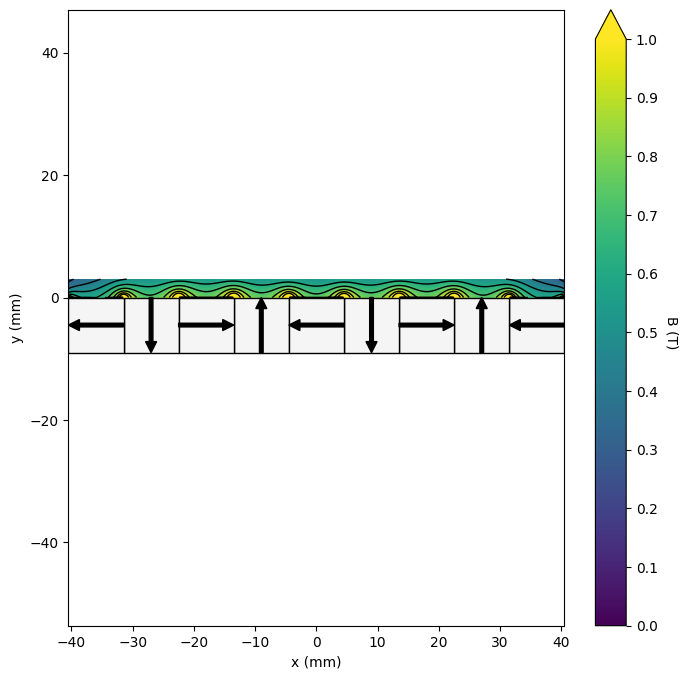

/Users/peter/Documents/recovered/Documents/4months/python/pymagnet/src/pymagnet/plots/_plot2D.py:284: RuntimeWarning: invalid value encountered in divide
  field.y.T / field.n.T,


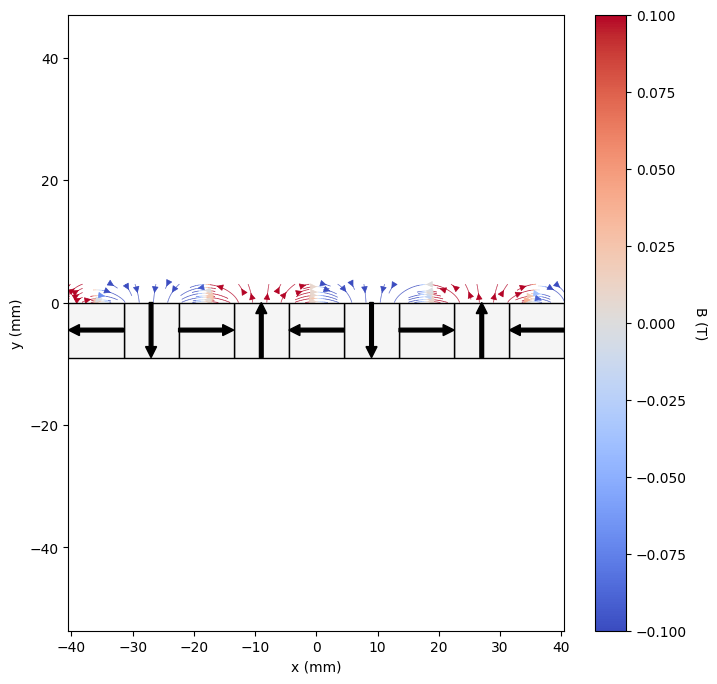

/Users/peter/Documents/recovered/Documents/4months/python/pymagnet/src/pymagnet/plots/_plot2D.py:299: RuntimeWarning: invalid value encountered in divide
  field.y.T / field.n.T,


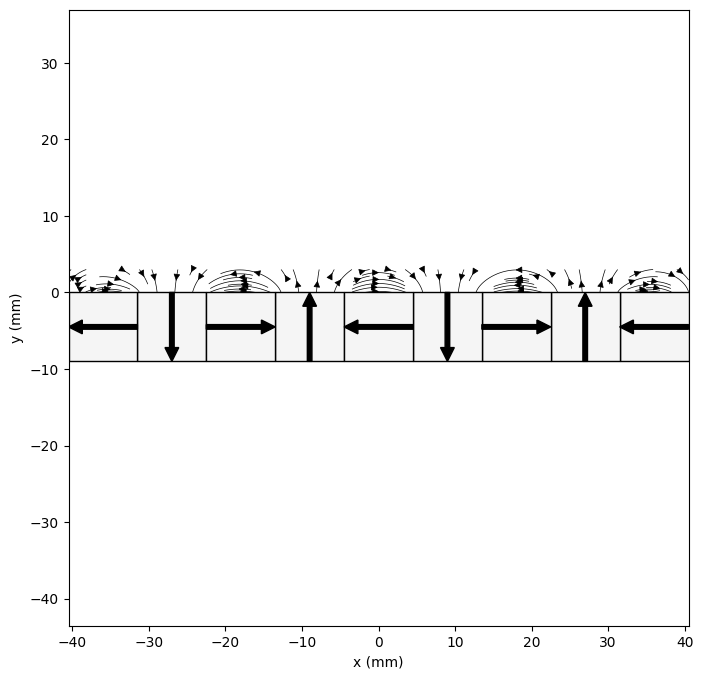

In [ ]:
pm.reset()  # clear magnet registry

N = 20
width = 12.0
height= 6.0
# gen_alternating_magnets(N=N, width=width, height=height, Jr=Jr)
gen_lin_halbach(N=N, width=width, height=height, Jr=Jr)


points = pm.grid2D(N * width / 2, 3.0, unit=unit, ymin=0, num_points=1001)

# Calculate the magnetic field due to all magnets in the registry
field = pm.get_field_2D(points)

# Plot the result, vector_plot = True toggles on the vector field plot
fig, _ = mplt.plot_2D_contour(
    points,
    field,
    cmin=0.0,  # minimum field value
    cmax=1.0,  # maximum field value
    vector_plot=True,  # plot the vector field
)




_, _ = mplt.plot_2D_contour(
    points,
    field,
    cmin=-0.1,  # minimum field value
    cmax=0.1,  # maximum field value
    cmap="coolwarm",  # set the colormap
    plot_type="streamplot",
    show_magnets=True,
)
_, _ = mplt.plot_2D_contour(points, field, plot_type="streamplot", show_magnets=True)


In [3]:
finite = field.n[np.isfinite(field.n)]
if finite.size == 0:
    min_v = mean_v = max_v = np.nan
else:
    min_v = float(finite.min())
    mean_v = float(finite.mean())
    max_v = float(finite.max())


In [4]:
try:
    df_stats
except NameError:
    df_stats = pl.DataFrame(
        {
            "config": pl.Series([], dtype=pl.Int64),
            "min": pl.Series([], dtype=pl.Float64),
            "mean": pl.Series([], dtype=pl.Float64),
            "max": pl.Series([], dtype=pl.Float64),
        }
    )


In [ ]:
config=0


new_row = pl.DataFrame(
    {
        "config": [int(config)],
        "min": [min_v],
        "mean": [mean_v],
        "max": [max_v],
    }
)

df_stats = pl.concat([df_stats, new_row], how="vertical")
